In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from sklearn.model_selection import train_test_split

In [44]:
df= pd.read_csv("AgricultureData.csv")
df.head()

,product_id,product_name,category,price_per_kg,units_shipped_kg,units_sold_kg,units_on_hand_kg,supplier,farm_location,sale_date
0,b12c721e-8301-4b08-8ac3-d435be9b8b32,Lamb,Livestock,14.10,19224,14905,4319,Organic Meats Co.,"O'Reillyboro, OR",2022-07-04
1,4a0f8862-c851-4073-bc17-3a3d93834902,Beef,Livestock,11.37,29504,4550,24954,Organic Meats Co.,"Lake Nora, AR",2023-10-21
2,be996df6-1780-4352-8b7d-1f927279aa49,Oranges,Fruits,2.59,1838,1722,116,Berry Fields,"East Friedaside, NM",2023-12-24
3,6c8adfc3-2114-4b78-a3e2-2269a6a0dc02,Milk,Dairy,1.34,6750,1232,5518,Fresh Dairy Farms,"East Javon, FL",2023-12-25
4,0bd5bf2b-be0a-4ba0-aa92-059021b169e3,Bananas,Fruits,1.78,48729,47020,1709,Golden Orchards,"Lake D'angelo, MN",2023-06-20


In [45]:
df.shape

(8893, 10)

In [46]:
rows,cols=df.shape
print("Number of rows :", rows)
print("Number of cols:", cols)

Number of rows : 8893
Number of cols: 10


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8893 entries, 0 to 8892
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        8893 non-null   object 
 1   product_name      8893 non-null   object 
 2   category          8893 non-null   object 
 3   price_per_kg      8893 non-null   float64
 4   units_shipped_kg  8893 non-null   int64  
 5   units_sold_kg     8893 non-null   int64  
 6   units_on_hand_kg  8893 non-null   int64  
 7   supplier          8893 non-null   object 
 8   farm_location     8893 non-null   object 
 9   sale_date         8893 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 486.4+ KB


In [48]:
df.describe()

,price_per_kg,units_shipped_kg,units_sold_kg,units_on_hand_kg
count,8893.000000,8893.000000,8893.000000,8893.000000
mean,3.641478,25471.785562,12545.278421,12926.507140
std,3.306348,14177.334372,10772.529049,10996.124845
min,0.400000,1005.000000,0.000000,0.000000
25%,0.970000,13228.000000,3642.000000,3890.000000
50%,2.680000,25468.000000,9643.000000,9805.000000
75%,5.300000,37964.000000,18832.000000,19622.000000
max,14.390000,50000.000000,49726.000000,49818.000000


In [49]:
df.isnull().sum()

product_id          0
product_name        0
category            0
price_per_kg        0
units_shipped_kg    0
units_sold_kg       0
units_on_hand_kg    0
supplier            0
farm_location       0
sale_date           0
dtype: int64

In [50]:
%pip install seaborn
import seaborn as sns

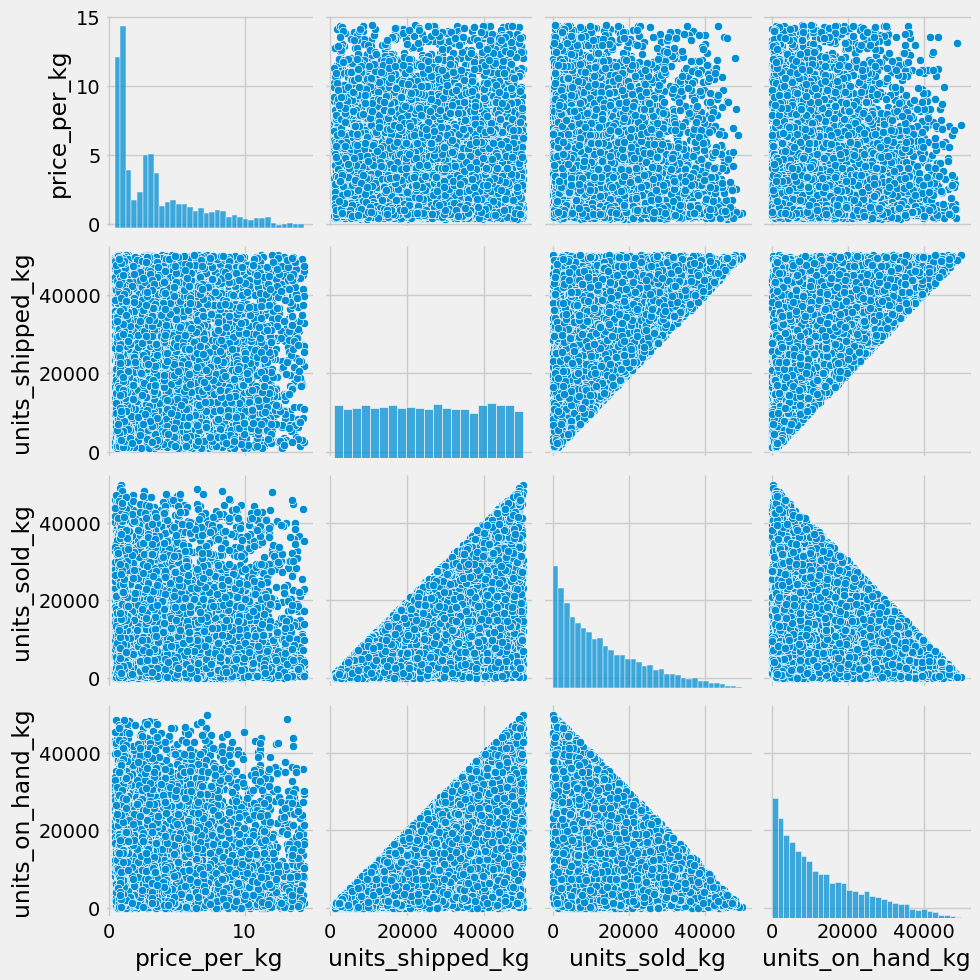

In [51]:
sns.pairplot(df)

<Axes: >

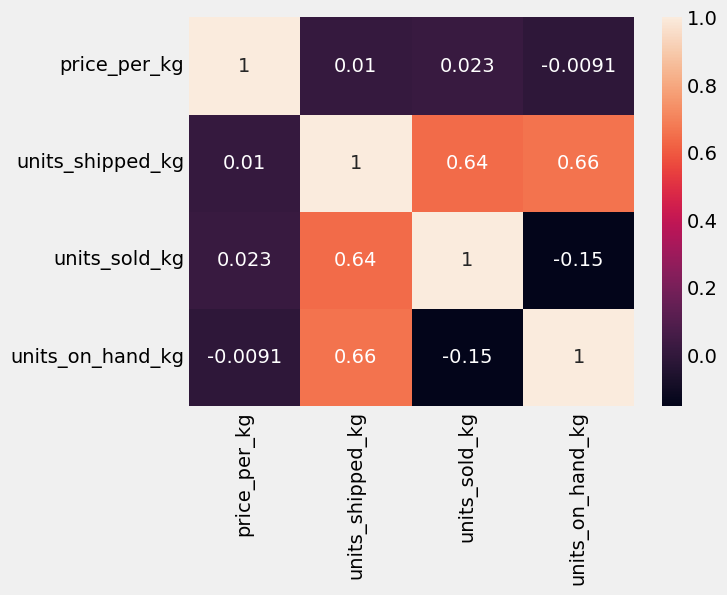

In [52]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [63]:
X = df[['price_per_kg', 'units_shipped_kg', 'units_on_hand_kg']]
y = df['units_sold_kg']

In [64]:
X.head()

,price_per_kg,units_shipped_kg,units_on_hand_kg
0,14.10,19224,4319
1,11.37,29504,24954
2,2.59,1838,116
3,1.34,6750,5518
4,1.78,48729,1709


In [65]:
y.head()

0    14905
1     4550
2     1722
3     1232
4    47020
Name: units_sold_kg, dtype: int64

In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=5)

In [67]:
print("X Train:",X_train.shape)
print("Y Train:",y_train.shape)

X Train: (7114, 3)
Y Train: (7114,)


In [68]:
print("X Test:",X_test.shape)
print("Y Test:",y_test.shape)

X Test: (1779, 3)
Y Test: (1779,)


In [69]:
#Build the Linear Regression
from sklearn.linear_model import LinearRegression

In [70]:
#Initialize the model
regressor=LinearRegression()

In [71]:
#Fit the model
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
#Predict the test data
y_pred=regressor.predict(X_test)

In [73]:
#Calculate the Results
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [74]:
#R square

R_Square=r2_score(y_test, y_pred)
print("R square:",R_Square)

#Mean Square Error
MSE=mean_squared_error(y_test, y_pred)
print("Mean Squared Error:",MSE)

#Mean Absolute Error
MAE=mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:",MAE)

#Accuracy
Accuracy = (1 - (MAE / np.mean(y_test))) * 100
print("Model Accuracy (%):", Accuracy)

R square: 1.0
Mean Squared Error: 5.270380052336867e-21
Mean Absolute Error: 6.217743402154317e-11
Model Accuracy (%): 99.9999999999995


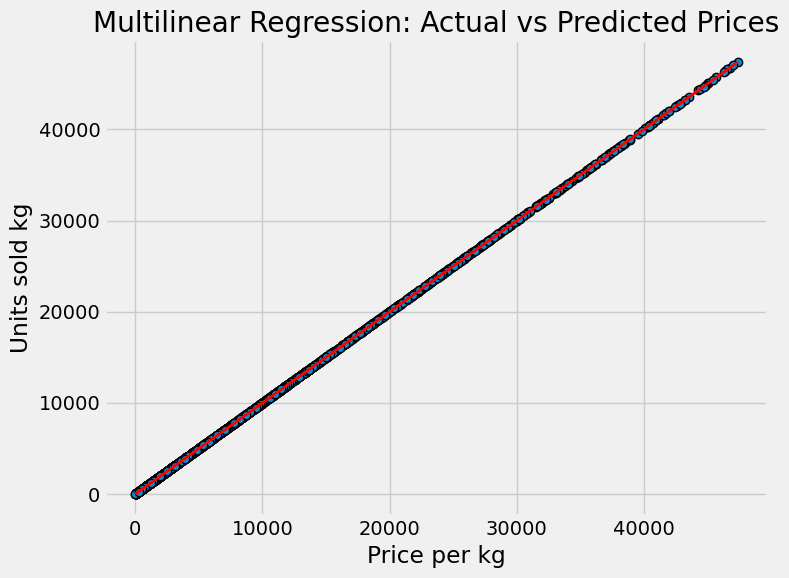

In [77]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,edgecolor='black',linewidth=1)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red',linewidth=2)
plt.xlabel("Price per kg")
plt.ylabel("Units sold kg")
plt.title("Multilinear Regression: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()